### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import shap
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/sklearn-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data and Simulation

In [2]:
# Load the uploaded label file
label_path = "/Users/melvankerja/Desktop/VSCode/Tesis/GalaxyZoo1_DR_table2 2.csv"
df = pd.read_csv(label_path)

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 667944 entries, 0 to 667943
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OBJID          667944 non-null  int64  
 1   RA             667944 non-null  str    
 2   DEC            667944 non-null  str    
 3   NVOTE          667944 non-null  int64  
 4   P_EL           667944 non-null  float64
 5   P_CW           667944 non-null  float64
 6   P_ACW          667944 non-null  float64
 7   P_EDGE         667944 non-null  float64
 8   P_DK           667944 non-null  float64
 9   P_MG           667944 non-null  float64
 10  P_CS           667944 non-null  float64
 11  P_EL_DEBIASED  667944 non-null  float64
 12  P_CS_DEBIASED  667944 non-null  float64
 13  SPIRAL         667944 non-null  int64  
 14  ELLIPTICAL     667944 non-null  int64  
 15  UNCERTAIN      667944 non-null  int64  
dtypes: float64(9), int64(5), str(2)
memory usage: 95.6 MB


In [3]:
df.head()

,OBJID,RA,DEC,NVOTE,P_EL,P_CW,P_ACW,P_EDGE,P_DK,P_MG,P_CS,P_EL_DEBIASED,P_CS_DEBIASED,SPIRAL,ELLIPTICAL,UNCERTAIN
0,587727178986356823,00:00:00.41,-10:22:25.7,59,0.610,0.034,0.000,0.153,0.153,0.051,0.186,0.610,0.186,0,0,1
1,587727227300741210,00:00:00.74,-09:13:20.2,18,0.611,0.000,0.167,0.222,0.000,0.000,0.389,0.203,0.797,1,0,0
2,587727225153257596,00:00:01.03,-10:56:48.0,68,0.735,0.029,0.000,0.147,0.074,0.015,0.176,0.432,0.428,0,0,1
3,587730774962536596,00:00:01.38,+15:30:35.3,52,0.885,0.019,0.000,0.058,0.019,0.019,0.077,0.885,0.077,0,1,0
4,587731186203885750,00:00:01.55,-00:05:33.3,59,0.712,0.000,0.000,0.220,0.068,0.000,0.220,0.640,0.290,0,0,1


In [ ]:
df['TARGET'] = df[['SPIRAL','ELLIPTICAL','UNCERTAIN']].idxmax(axis=1)

mapping = {
    'UNCERTAIN':0,
    'ELLIPTICAL':1,
    'SPIRAL':2
}

df['TARGET'] = df[['SPIRAL','ELLIPTICAL','UNCERTAIN']].idxmax(axis=1).map(mapping)
df = df.drop(columns=['SPIRAL','ELLIPTICAL','UNCERTAIN'])
print("\nDistribusi target_class:")
print(df["TARGET"].value_counts())

drop_cols = ["OBJID", "RA","DEC"]

df = df.drop(columns=drop_cols)

print("\nKolom setelah drop ID:")
print(df.columns)

Dataset shape awal: (667944, 16)
                OBJID           RA          DEC  NVOTE   P_EL   P_CW  P_ACW  \
0  587727178986356823  00:00:00.41  -10:22:25.7     59  0.610  0.034  0.000   
1  587727227300741210  00:00:00.74  -09:13:20.2     18  0.611  0.000  0.167   
2  587727225153257596  00:00:01.03  -10:56:48.0     68  0.735  0.029  0.000   
3  587730774962536596  00:00:01.38  +15:30:35.3     52  0.885  0.019  0.000   
4  587731186203885750  00:00:01.55  -00:05:33.3     59  0.712  0.000  0.000   

   P_EDGE   P_DK   P_MG   P_CS  P_EL_DEBIASED  P_CS_DEBIASED  SPIRAL  \
0   0.153  0.153  0.051  0.186          0.610          0.186       0   
1   0.222  0.000  0.000  0.389          0.203          0.797       1   
2   0.147  0.074  0.015  0.176          0.432          0.428       0   
3   0.058  0.019  0.019  0.077          0.885          0.077       0   
4   0.220  0.068  0.000  0.220          0.640          0.290       0   

   ELLIPTICAL  UNCERTAIN  
0           0          1  
1    

In [ ]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]


# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["TARGET"] = y.values
df_final

,NVOTE,P_EL,P_CW,P_ACW,P_EDGE,P_DK,P_MG,P_CS,P_EL_DEBIASED,P_CS_DEBIASED,TARGET
0,0.611111,0.610,0.034,0.000,0.153,0.153,0.051,0.186,0.610,0.186,0
1,0.155556,0.611,0.000,0.167,0.222,0.000,0.000,0.389,0.203,0.797,2
2,0.711111,0.735,0.029,0.000,0.147,0.074,0.015,0.176,0.432,0.428,0
3,0.533333,0.885,0.019,0.000,0.058,0.019,0.019,0.077,0.885,0.077,1
4,0.611111,0.712,0.000,0.000,0.220,0.068,0.000,0.220,0.640,0.290,0
...,...,...,...,...,...,...,...,...,...,...,...
667939,0.344444,0.171,0.800,0.000,0.029,0.000,0.000,0.829,0.057,0.943,2
667940,0.188889,0.810,0.048,0.000,0.095,0.048,0.000,0.143,0.758,0.193,0
667941,0.266667,0.286,0.000,0.071,0.393,0.179,0.071,0.464,0.099,0.603,0
667942,0.211111,0.391,0.000,0.043,0.000,0.130,0.435,0.043,0.390,0.045,0


In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

Data sebelum SMOTETomek
Shape X: (667944, 10)
Shape y: (667944,)

Distribusi kelas sebelum SMOTETomek:
TARGET
0    415529
1     62190
2    190225
Name: count, dtype: int64
  Kelas 0: 415529 sampel (62.21%)
  Kelas 1: 62190 sampel (9.31%)
  Kelas 2: 190225 sampel (28.48%)

Class Weights
  Kelas 0: 0.5358
  Kelas 1: 3.5801
  Kelas 2: 1.1704

Data setelah SMOTETomek
Shape X_resampled: (1227397, 10)
Shape y_resampled: (1227397,)

Distribusi kelas setelah SMOTETomek:
  Kelas 0: 405971 sampel (33.08%)
  Kelas 1: 412035 sampel (33.57%)
  Kelas 2: 409391 sampel (33.35%)


### Feature Analysis

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=209,
    class_weight="balanced"
)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=209, stratify=y_resampled
)

# Kemudian dari sisa (80%), pisahkan validation (20% dari total = 25% dari sisa)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)

rf.fit(X_train, y_train)
importance = rf.feature_importances_

In [8]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print("Top RF Feature Importance")
print(rf_importance.head(10))

Top RF Feature Importance
P_EL_DEBIASED    0.276966
P_CS_DEBIASED    0.226201
P_EL             0.171646
P_CS             0.125166
P_DK             0.075660
P_EDGE           0.049970
P_ACW            0.022133
NVOTE            0.018799
P_MG             0.016915
P_CW             0.016545
dtype: float64


In [9]:
result = permutation_importance(rf, X_test, y_test)
importance = result.importances_mean
perm_importance = pd.Series(
    importance,
    index=X_test.columns
).sort_values(ascending=False)

print("\nTop Permutation Importance")
print(perm_importance.head(10))


Top Permutation Importance
P_CS_DEBIASED    0.382175
P_EL_DEBIASED    0.264373
P_EL             0.180851
P_DK             0.026904
P_CS             0.023950
P_EDGE           0.010300
NVOTE            0.008111
P_MG             0.007036
P_ACW            0.004517
P_CW             0.004054
dtype: float64



Top Permutation Importance
P_CS_DEBIASED    0.430482
P_EL_DEBIASED    0.318774
P_EL             0.215369
P_CS             0.051058
P_DK             0.049136
P_EDGE           0.029366
NVOTE            0.016346
P_ACW            0.014632
P_MG             0.013855
P_CW             0.013235
dtype: float64


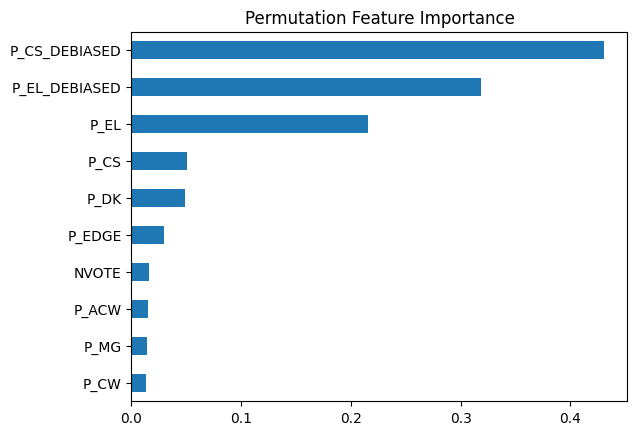

In [8]:
perm = permutation_importance(
    rf,
    X_resampled,
    y_resampled,
    n_repeats=10,
    random_state=209,
    scoring="f1_macro"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_resampled.columns
).sort_values(ascending=False)

print("\nTop Permutation Importance")
print(perm_importance.head(15))

perm_importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.show()

               RF_Importance  Permutation_Importance
P_CS_DEBIASED       0.226201                0.382175
P_EL_DEBIASED       0.276966                0.264373
P_EL                0.171646                0.180851
P_DK                0.075660                0.026904
P_CS                0.125166                0.023950
P_EDGE              0.049970                0.010300
NVOTE               0.018799                0.008111
P_MG                0.016915                0.007036
P_ACW               0.022133                0.004517
P_CW                0.016545                0.004054


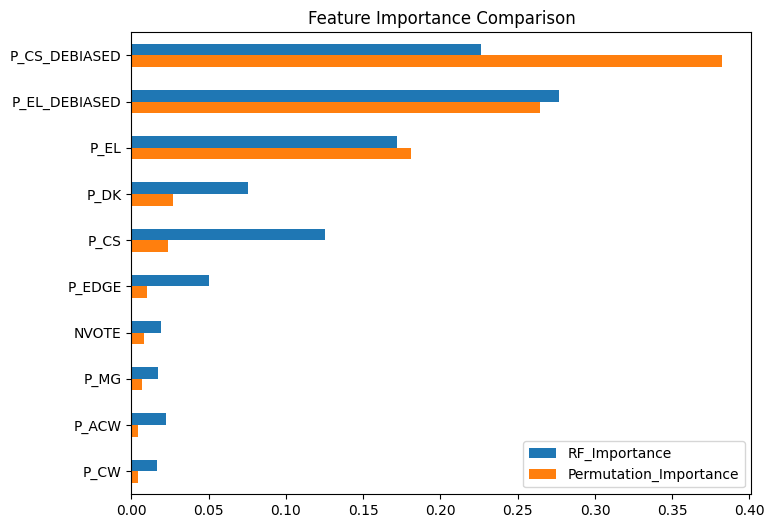

In [10]:
importance_df = pd.DataFrame({
    "RF_Importance": rf_importance,
    "Permutation_Importance": perm_importance
})

importance_df = importance_df.sort_values(
    by="Permutation_Importance",
    ascending=False
)

print(importance_df.head(20))

importance_df.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Feature Importance Comparison")
plt.show()

In [11]:
explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(300, random_state=209)

shap_values = explainer.shap_values(X_sample)

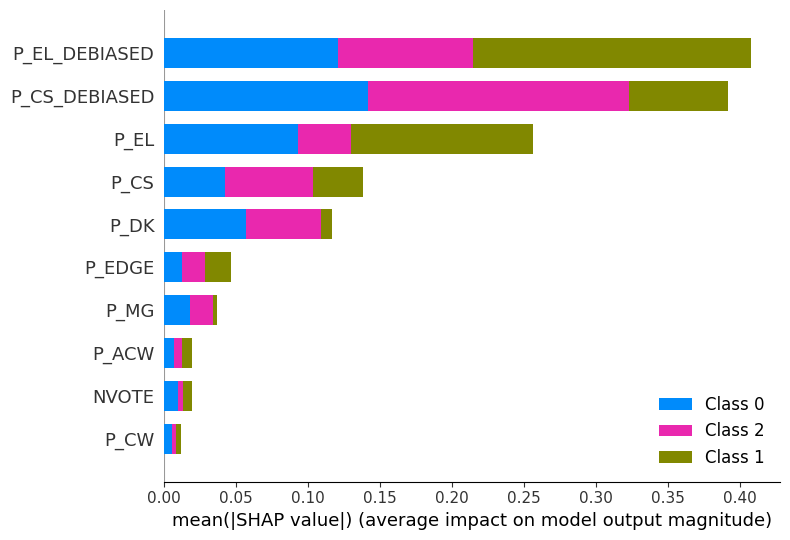

In [12]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [14]:
feature_names = X_sample.columns
class_names = ['Intermediate','Non-Spiral','Spiral']

shap_importance = {}

for i, class_name in enumerate(class_names):

    vals = np.abs(shap_values[:,:,i]).mean(axis=0)

    shap_importance[class_name] = vals

df_shap = pd.DataFrame(shap_importance, index=feature_names)

print(df_shap)

               Intermediate  Non-Spiral    Spiral
NVOTE              0.009453    0.006242  0.003626
P_EL               0.093148    0.126246  0.036987
P_CW               0.005401    0.003629  0.002619
P_ACW              0.007052    0.007421  0.005096
P_EDGE             0.012509    0.017880  0.015790
P_DK               0.057005    0.007889  0.051906
P_MG               0.017834    0.002611  0.016167
P_CS               0.042060    0.034287  0.061514
P_EL_DEBIASED      0.121046    0.193118  0.093520
P_CS_DEBIASED      0.141798    0.068735  0.181055
